# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [5]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, norm_field
from knot_funcs import propTF

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

# Create field & modes of interest following yaml configuration

Initialize coordinate space and system parameters that we will use to define our field.

In [14]:
index = 0

stream = open(f"configs/ga{index}.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 

num_phase_maps_near = cnfg['num_phase_maps_near']
num_phase_maps_far = cnfg['num_phase_maps_far']

num_of_phase_maps = num_phase_maps_near + num_phase_maps_far # Total number of phase maps
instance_name = cnfg['ga_instance'] # directory name of best phases

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']

# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)

# Propagation Distance 
prop_dist = 0

# Let's apply a rotation
rot_phi = eval(cnfg['rot_angle'])

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Apply rotation operator on coords 

xx,yy=np.meshgrid(X ,Y)

r, phi= cart2pol(xx, yy)

#dr = r[1,0] - r[0,0]
#dphi = phi[1,0] - phi[0,0]

''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []

if (num_of_output_chans==2):
    output_chans = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans, chan_sep=channel_seperation)
else: 
    output_chans = output_chan_triangle(X, Y, output_chan_width, maxx, chan_sep=channel_seperation)

#output_chans = output_chan_triangle(X, Y, output_chan_width, maxx, chan_sep=channel_seperation) # This can only be used if we are explcitly sorting three channels

if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        list_of_OAMs.append(oamModes(field, output_chans[ii]))
else:
    for ii in range(len(LG_modes)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        list_of_OAMs.append(oamModes(field, output_chans[ii]))

We can optionally apply rotations/translations onto the knotted field

In [7]:
# Rotates the incident knot by rot_phi

def create_rotated_knots(rot_phi):
    
    # Apply rotation operator on coords. Update: The rotation should be 
    # X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
    # Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

    xx,yy=np.meshgrid(X ,Y)
    
    xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
    yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

    r, phi= cart2pol(xx_rot,yy_rot)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs


# Translates the incident knot by x_trans/y_trans

def create_translated_knots(x_trans, y_trans):

    xx,yy=np.meshgrid(X ,Y);
    
    xx_trans = xx + x_trans
    yy_trans = yy + y_trans 

    r, phi= cart2pol(xx_trans,yy_trans)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs

Plot the incident field

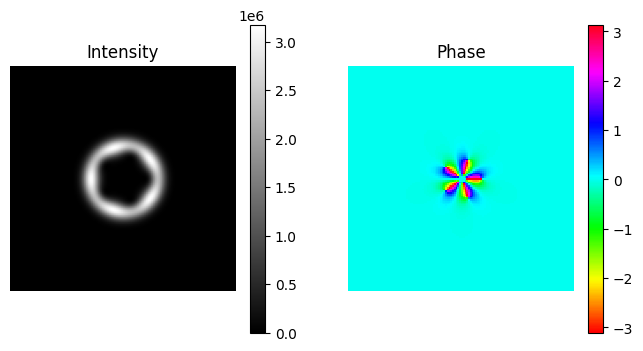

In [8]:
field = norm_field(list_of_OAMs[1].oamBeam, h)
TotInt(field)

Now, prepare the phase maps. This time, we load up the genetic instances

In [ ]:
import pickle

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)

tref_figure8_G1000_normDouble


Compute phase screens and plot them 

In [9]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=np.complex128)

# Compute phase screens and plot them 
for ii in range(num_of_phase_maps):
    # Apply extra gaussian filter on output data 
    phase_out[ii] =sp.ndimage.gaussian_filter(phase_out[ii], sigma=maxx*GFilterStrength)
    phase_maps[ii]= np.exp(1j*phase_out[ii])


ps_index = 0
fig, ax = plt.subplots(1,1, figsize=(8,8))
first = ax.imshow(np.angle(phase_maps[ps_index]), cmap='rainbow')
ax.set_title(f"Phase Screen {ps_index+1}")
c1 = fig.colorbar(first, ax=ax)

plt.show()

NameError: name 'phase_out' is not defined

# Simulated Experiment

Now, we proceed to compute our chosen, simulated experiment. We can run the experiment from here. 

In [10]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, norm_field
from knot_funcs import propTF

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

Determine the experiment we are going to design

In [ ]:
simulateLens = cnfg['simulateLens']
multiPhase = cnfg['multiPhase']
multiPhaseLens = cnfg['multiPhaseLens']

z_o = cnfg['z_o']
fourier_lens = cnfg['fourier_lens']

Choose the LG beam to analyze

In [16]:
mode_num = 0
field = norm_field(list_of_OAMs[mode_num].oamBeam, h)

Modulate the beam with the first phase screen (if applicable).

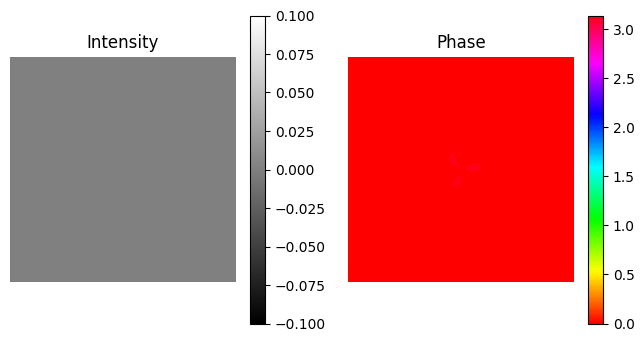

In [17]:
# modulate the field by the first phase map 

field_mod_1 = field*phase_maps[0]

# plot the beam

TotInt(field_mod_1)

Depending on what kind of experiment we choose to realize, we may opt to implement multiple phase screens. 

### Multiple Phase Screens only

In this experiment, we simply propagate the beam through multiple phase maps that we opt to optimize

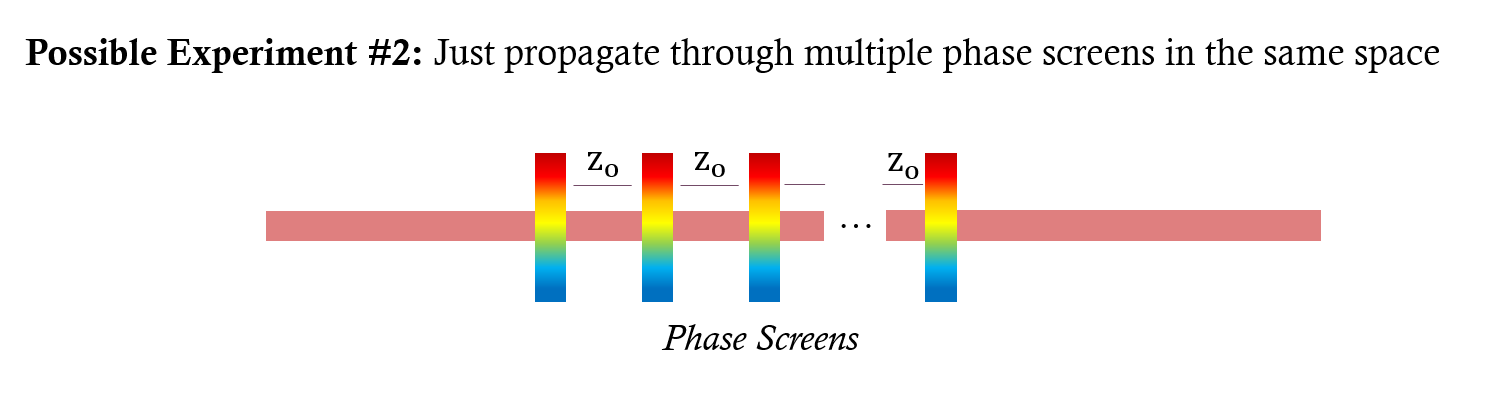

In [ ]:
if (multiPhase): # Propagate the field by a distance z_o and apply the second phase screen
            field_after = field_mod_1

            for ii in range(1, len(phase_maps)):
                # Propagate the beam by a distance z_o
                field_after = propTF(field_after, maxx, la, z_o)

                # Apply the next phase map (if applicable)
                field_after = field_after*phase_maps[ii]

            # Propagate the beam one final time and observe the final field

            final_field = propTF(field_after, maxx, la, z_o)


At this point, plot the final beam

In [ ]:
TotInt(final_field)

#### Multiple Phases with Lens

Alternatively, we create stacks of plates in the near field, then apply a lens (i.e. take the fourier transform)

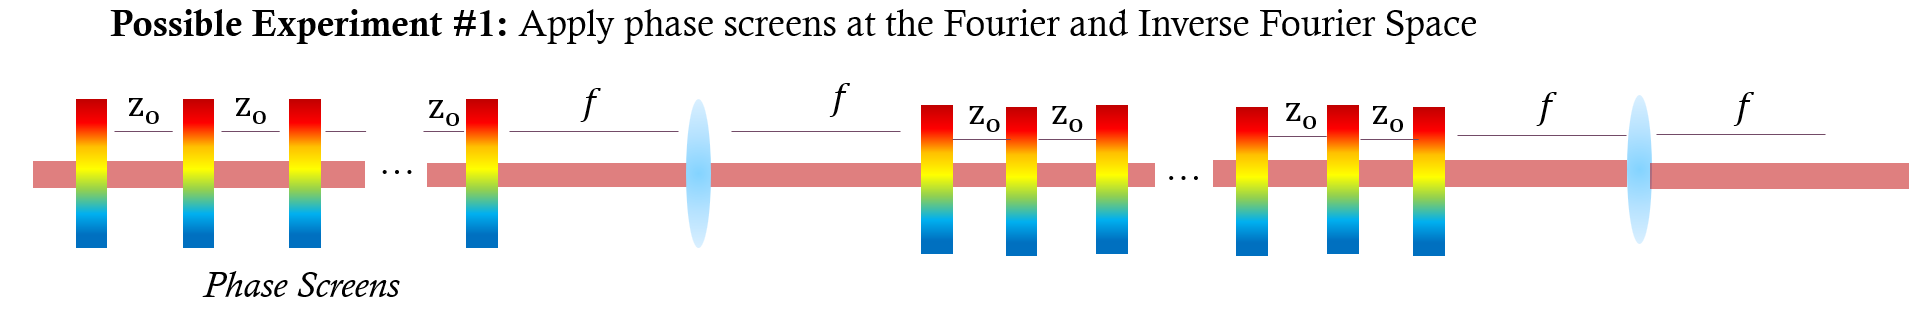

In [ ]:
if (multiPhaseLens): # Multi-phase experiment with the lens
        field_after = field_mod_1

        for ii in range(1, 1+num_phase_maps_near):
            # Propagate the beam by a distance z_o 
            field_after = propTF(field_after, maxx, la, z_o)
            # Apply the next phase map in the near field (if applicable)
            field_after = field_after*phase_maps[ii]
                
        # Fourier transform the beam into the far field
        field_lens = fftshift(fft2(field_after))


Plot the field at the first focal plane of the lens

In [ ]:
TotInt(field_lens)

Now, modulate the beam in the far field (if applicable)

In [ ]:
# What happens next depends on whether we have one or two phase maps
        
if (num_phase_maps_far==0):
    # Compute the field intensity 
    final_field = field_lens
        
else:
    # Modulate the field by the first far field map
    field_mod_2 = field_lens*phase_maps[num_phase_maps_near]

    if (multiPhaseLens):
        field_after_2 = field_mod_2

        for jj in range(1+num_phase_maps_near, num_of_phase_maps):
            # Propagate the beam 
            field_after_2 = propTF(field_after_2, maxx, la, z_o)
            # Apply phase to beam 
            field_after_2 = field_after_2*phase_maps[jj]

        # Apply inverse fourier transform onto beam
        field_lens_2 = ifft2(ifftshift(field_after_2))

    final_field = field_lens_2

Make a plot of the final field

In [ ]:
TotInt(final_field)

### Standard Experiment 

This is the same procedure that we follow from Robert Fickler's paper, and what we have been doing up until now.
 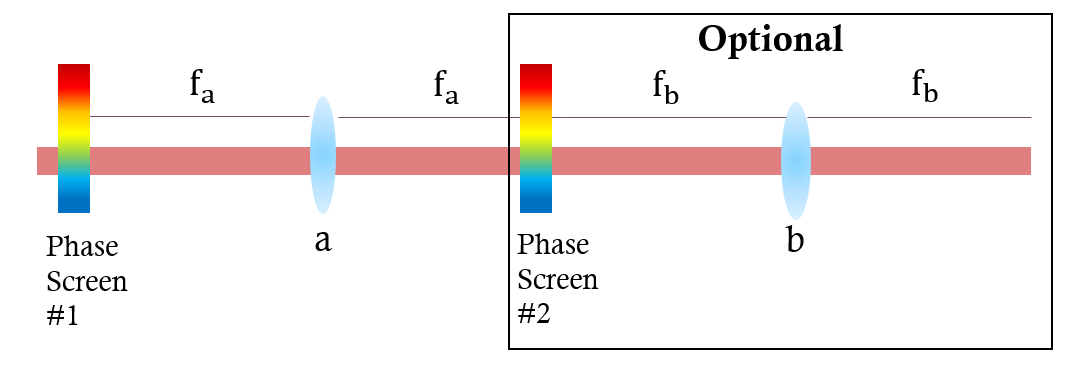

In [ ]:
if (simulateLens): # We simulate Faunhofer Diffraction for a more accurate representation of lens propagation
    field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
    
else: # Compute the field at the front focal plane of the lens
        field_lens = fftshift(fft2(field_mod_1))

Make a plot of the field at the focal length of the lens 

In [18]:
TotInt(field_lens)

NameError: name 'field_lens' is not defined

Simulating the second phase map

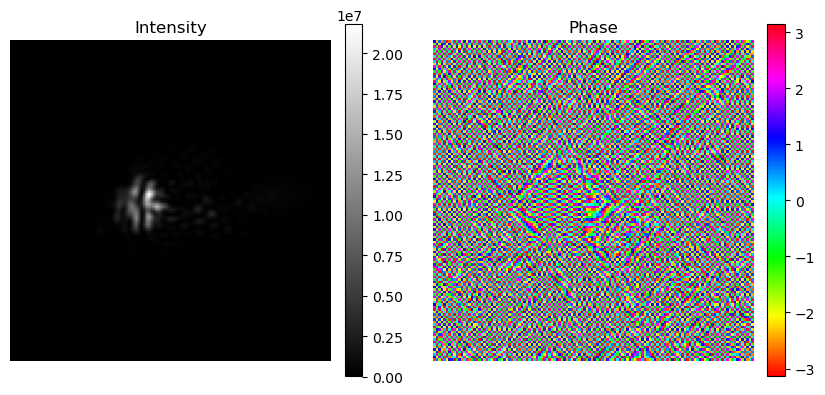

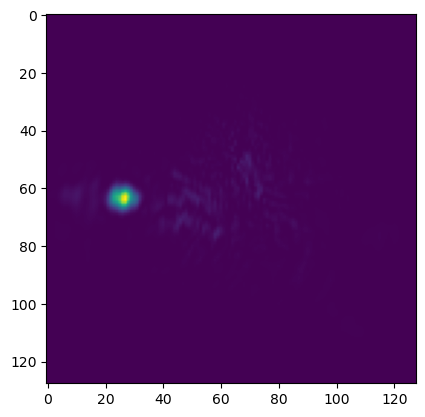

In [ ]:
field_mod_2 = field_lens*phase_maps[num_phase_maps_near]

if simulateLens:
    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)

else:
    field_lens_2 = ifft2(ifftshift(field_mod_2))

final_field = field_lens_2

Make a plot of the field

In [ ]:
TotInt(final_field)

# Compute the normalized sorting probability 

In [108]:
simulateLens = False
sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(phase_maps, list_of_OAMs)

0.016533672705571805
1.0
224.72621268270808
0.9999999999999999


Compute the crosstalk matrix

[[0.46094782 0.00285215]
 [0.0008829  0.58996742]]
0.5254576207797773
0.001867529091755843


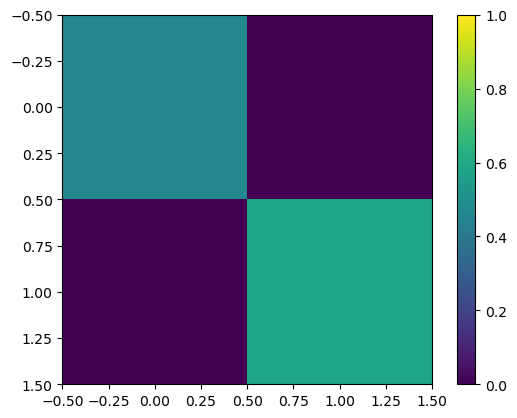

In [109]:
plt.figure()
plt.imshow(crosstalk_matrix, vmin=0.0, vmax=1.0)
plt.colorbar()

print(crosstalk_matrix)
print(np.mean([crosstalk_matrix[0,0], crosstalk_matrix[1,1]]))
print(np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]]))

# Effect of Rotation on Hologram 

In [ ]:
rotate_angles = np.linspace(0, 2*np.pi, num=50)
mean_effs = []
mean_crosses = []

for angle in rotate_angles: 
    # Generate the rotated fields
    list_of_rotated_OAMs = create_rotated_knots(angle)
    # Compute the crosstalk matrix 
    simulateLens = False
    sorting_performance, crosstalk_matrix = compute_sorting_performance(phase_maps, list_of_rotated_OAMs)
    
    # Report the mean on the detector efficency, crosstalk. 
    #mean_eff = np.mean([crosstalk_matrix[0,0], crosstalk_matrix[1,1]])
    #mean_cross = np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]])
    
    mean_eff = crosstalk_matrix[0,0]
    mean_cross = crosstalk_matrix[1,0]
    
    mean_effs.append(mean_eff)
    mean_crosses.append(mean_cross)

In [ ]:
plt.plot(rotate_angles, mean_effs, label='Mean Efficiency')
plt.plot(rotate_angles, mean_crosses, label='Mean Crosstalk')
plt.legend()
plt.show()

# Effect of Translation on Field Performance

In [76]:
x_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)
y_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)

effs = []
crosses = []

# How does the detector efficency and crosstalk change with the Trefoil? with the Cinquefoil? 

mode = 1 # 0 means trefoil, 1 means cinquefoil

for x_trans in x_translate:
    eff_row = []
    cross_row = []
    
    for y_trans in y_translate:
        
        # Generated the translated fields
        list_of_translated_OAMs = create_translated_knots(x_trans, y_trans)
        
        # Compute the crosstalk matrix
        simulateLens = False
        sorting_performance, crosstalk_matrix = compute_sorting_performance(phase_maps, list_of_translated_OAMs)
        
        # Extract the desired crosstalk/detector efficency 
        eff_row.append(crosstalk_matrix[mode,1])
        cross_row.append(crosstalk_matrix[mode,0])
    
    effs.append(eff_row)
    crosses.append(cross_row)

0.016533672705571805
128.0
61.855021159695745
127.99999999999999
0.016533672705571805
128.0
61.85502115969586
128.0
0.016533672705571805
128.0
61.855021159695944
127.99999999999999
0.016533672705571805
128.0
61.85502115969601
128.0
0.016533672705571805
128.0
61.85502115969605
128.0
0.016533672705571805
128.0
61.85502115969608
128.0
0.016533672705571805
128.0
61.85502115969611
128.0
0.016533672705571805
128.0
61.85502115969612
128.0
0.016533672705571805
128.0
61.85502115969614
127.99999999999999
0.016533672705571805
128.0
61.85502115969615
128.0
0.016533672705571805
128.0
61.85502115969616
127.99999999999999
0.016533672705571805
128.0
61.855021159696165
127.99999999999999
0.01653367270557181
127.99999999999999
61.855021159696165
128.0
0.016533672705571805
128.0
61.855021159696165
128.0
0.016533672705571805
128.0
61.85502115969617
127.99999999999999
0.016533672705571805
128.0
61.85502115969617
127.99999999999999
0.016533672705571805
128.0
61.85502115969617
128.0
0.016533672705571805
128.

0.016533672705571805
128.0
61.85502115969643
128.0
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
128.0
0.016533672705571805
128.00000000000003
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
128.0
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.85502115969643
128.0
0

0.016533672705571805
128.0
61.855021159696534
128.0
0.01653367270557181
127.99999999999999
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.00000000000003
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999997
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969654
127.99999999999997
0.01653

0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.00000000000003
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969657
127.99999999999999
0.016533672705571805
128.0
61.85502115969658
128.0
0.016

0.016533672705571805
128.0
61.85502115969659
128.0
0.01653367270557181
127.99999999999999
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571

...

0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.00000000000003
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.855021159696605
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.01653367270557

0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.00000000000003
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
1

0.016533672705571805
128.0
61.8550211596965
128.00000000000003
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.00000000000003
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969656
128.0
0.016533672705571805
128.00000000000003
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.855021159696584
127.99999999999999
0.01653367270557181
127.99999999999999
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.00000000000003
0.016533672705571805
128.0
6

0.016533672705571805
128.0
61.85502115969649
128.0
0.016533672705571805
128.0
61.85502115969652
127.99999999999999
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
128.0
0.016533672705571805
128.0
61.85502115969657
127.99999999999999
0.016533672705571805
128.0
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.00000000000003
0.016533672705571805
128.00000000000003
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.00000000000003
61.85502115969658
128.0
0.016533672705

128.00000000000003
0.016533672705571805
128.0
61.855021159696506
128.0
0.016533672705571805
128.00000000000003
61.85502115969651
128.00000000000003
0.016533672705571805
128.0
61.855021159696534
127.99999999999999
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.01653367270557181
127.99999999999999
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
127.99999999999999
0.016533672705571805
128.00000000000003
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.00000000000003
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
127.99999999999999
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
127.99999999999999
0.016533672705571805
128.0
61.

Make a cool 3D plot because everyone likes 3D plots boy howdy

(0.0, 0.1)

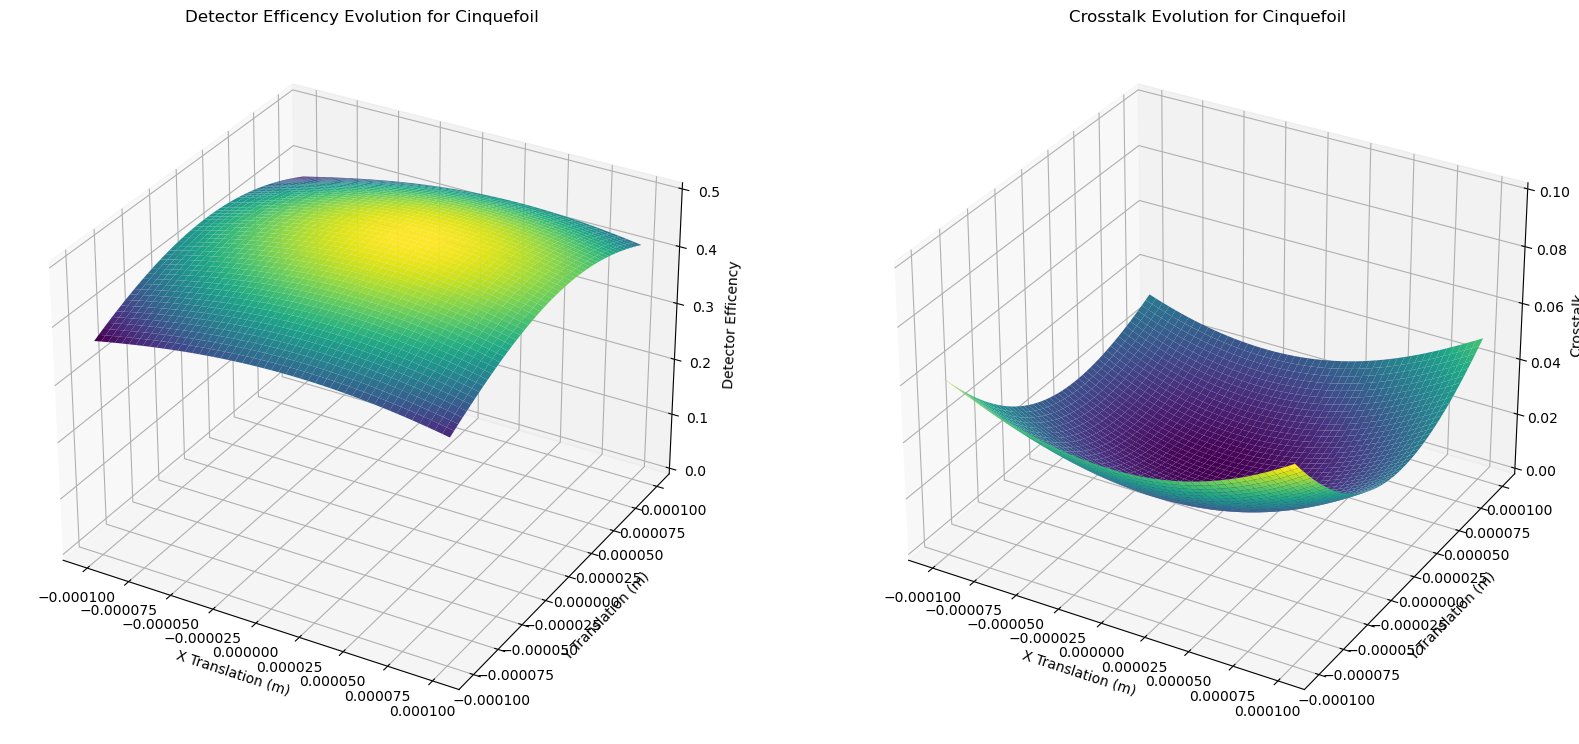

In [79]:
from mpl_toolkits.mplot3d import Axes3D

X_trans, Y_trans = np.meshgrid(x_translate, y_translate)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X_trans, Y_trans, np.array(effs), cmap='viridis')
ax.set_xlabel('X Translation (m)')
ax.set_ylabel('Y Translation (m)')
ax.set_zlabel('Detector Efficency')
ax.set_title('Detector Efficency Evolution for Cinquefoil')
ax.set_zlim([0, 0.5])

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_trans, Y_trans, np.array(crosses), cmap='viridis')
ax2.set_xlabel('X Translation (m)')
ax2.set_ylabel('Y Translation (m)')
ax2.set_zlabel('Crosstalk')
ax2.set_title('Crosstalk Evolution for Cinquefoil')
ax2.set_zlim([0, 0.1])